In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap


In [2]:
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


In [3]:
from imblearn.over_sampling import SMOTE

In [4]:
# Load the dataset
df = pd.read_csv("data_csv.csv")

In [5]:
df

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,1,0,0,0,0,0,0,1,1,0,...,Yes,Yes,1,Yes,F,middle eastern,Yes,No,Family Member,No
1,2,1,1,0,0,0,1,1,0,0,...,Yes,Yes,2,Yes,M,White European,Yes,No,Family Member,Yes
2,3,1,0,0,0,0,0,1,1,0,...,Yes,Yes,4,Yes,M,Middle Eastern,Yes,No,Family Member,Yes
3,4,1,1,1,1,1,1,1,1,1,...,Yes,Yes,2,Yes,M,Hispanic,No,No,Family Member,Yes
4,5,1,1,0,1,1,1,1,1,1,...,Yes,Yes,1,Yes,F,White European,No,No,Family Member,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,1981,0,0,0,0,0,0,0,0,0,...,No,No,1,No,M,Middle Eastern,No,No,Health Care Professional,No
1981,1982,0,0,0,0,0,0,0,0,0,...,No,No,1,No,F,south asian,No,No,Health Care Professional,No
1982,1983,0,0,0,0,0,0,0,0,0,...,No,No,1,No,M,White European,No,No,Health Care Professional,Yes
1983,1984,0,0,0,0,0,0,0,0,0,...,No,No,1,No,M,Middle Eastern,No,No,Health Care Professional,No


In [6]:
# Early EDA#
#0 means number of patients in column, 1 means number of rows
print(f"Patients: {df.shape[0]}, Columns: {df.shape[1]}")

Patients: 1985, Columns: 28


In [7]:
df.head()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,1,0,0,0,0,0,0,1,1,0,...,Yes,Yes,1,Yes,F,middle eastern,Yes,No,Family Member,No
1,2,1,1,0,0,0,1,1,0,0,...,Yes,Yes,2,Yes,M,White European,Yes,No,Family Member,Yes
2,3,1,0,0,0,0,0,1,1,0,...,Yes,Yes,4,Yes,M,Middle Eastern,Yes,No,Family Member,Yes
3,4,1,1,1,1,1,1,1,1,1,...,Yes,Yes,2,Yes,M,Hispanic,No,No,Family Member,Yes
4,5,1,1,0,1,1,1,1,1,1,...,Yes,Yes,1,Yes,F,White European,No,No,Family Member,Yes


In [8]:
df.tail()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
1980,1981,0,0,0,0,0,0,0,0,0,...,No,No,1,No,M,Middle Eastern,No,No,Health Care Professional,No
1981,1982,0,0,0,0,0,0,0,0,0,...,No,No,1,No,F,south asian,No,No,Health Care Professional,No
1982,1983,0,0,0,0,0,0,0,0,0,...,No,No,1,No,M,White European,No,No,Health Care Professional,Yes
1983,1984,0,0,0,0,0,0,0,0,0,...,No,No,1,No,M,Middle Eastern,No,No,Health Care Professional,No
1984,1985,0,0,0,0,0,0,0,0,0,...,No,No,1,No,M,White European,No,No,Health Care Professional,Yes


In [9]:
df.describe()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,Social_Responsiveness_Scale,Age_Years,Qchat_10_Score,Childhood Autism Rating Scale
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1976.000000,1985.000000,1946.000000,1985.000000
mean,993.000000,0.299244,0.238287,0.213098,0.272040,0.278589,0.306297,0.345088,0.243829,0.259950,0.446348,3.074393,9.624685,4.234841,1.701763
std,573.164462,0.458042,0.426143,0.409600,0.445123,0.448418,0.461071,0.475517,0.429499,0.438717,0.497238,3.680263,4.302416,2.898247,1.015367
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,497.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,2.000000,1.000000
50%,993.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,4.000000,1.000000
75%,1489.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,5.000000,14.000000,6.000000,2.000000
max,1985.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,18.000000,10.000000,4.000000


In [10]:
# number of missing values
df.isnull().sum()

,0
CASE_NO_PATIENT'S,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0


In [11]:
### data cleaning (sort out duplicates or missing data)###

In [12]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.drop(columns=["CASE_NO_PATIENT'S"], inplace=True)
print(f"Patients: {df.shape[0]}, Columns: {df.shape[1]}")

Patients: 1923, Columns: 27


In [13]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,0,0,0,0,0,0,1,1,0,1,...,Yes,Yes,1,Yes,F,middle eastern,Yes,No,Family Member,No
1,1,1,0,0,0,1,1,0,0,0,...,Yes,Yes,2,Yes,M,White European,Yes,No,Family Member,Yes
2,1,0,0,0,0,0,1,1,0,1,...,Yes,Yes,4,Yes,M,Middle Eastern,Yes,No,Family Member,Yes
3,1,1,1,1,1,1,1,1,1,1,...,Yes,Yes,2,Yes,M,Hispanic,No,No,Family Member,Yes
4,1,1,0,1,1,1,1,1,1,1,...,Yes,Yes,1,Yes,F,White European,No,No,Family Member,Yes


In [14]:
#Encoding — convert categorical to numerical
le = LabelEncoder()
df['Speech Delay/Language Disorder'] = le.fit_transform(df['Speech Delay/Language Disorder'])
df['Learning disorder'] = le.fit_transform(df['Learning disorder'])
df['Genetic_Disorders'] = le.fit_transform(df['Genetic_Disorders'])
df['Depression'] = le.fit_transform(df['Depression'])
df['Global developmental delay/intellectual disability'] = le.fit_transform(df['Global developmental delay/intellectual disability'])
df['Social/Behavioural Issues'] = le.fit_transform(df['Social/Behavioural Issues'])
df['Anxiety_disorder'] = le.fit_transform(df['Anxiety_disorder'])
df['Sex'] = le.fit_transform(df['Sex'])
df['Jaundice'] = le.fit_transform(df['Jaundice'])
df['Family_mem_with_ASD'] = le.fit_transform(df['Family_mem_with_ASD'])
df['ASD_traits'] = le.fit_transform(df['ASD_traits'])
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,0,0,0,0,0,0,1,1,0,1,...,1,1,1,1,0,middle eastern,1,0,Family Member,0
1,1,1,0,0,0,1,1,0,0,0,...,1,1,2,1,1,White European,1,0,Family Member,1
2,1,0,0,0,0,0,1,1,0,1,...,1,1,4,1,1,Middle Eastern,1,0,Family Member,1
3,1,1,1,1,1,1,1,1,1,1,...,1,1,2,1,1,Hispanic,0,0,Family Member,1
4,1,1,0,1,1,1,1,1,1,1,...,1,1,1,1,0,White European,0,0,Family Member,1


In [15]:
#Label encoding pd
df['Ethnicity'] = df['Ethnicity'].str.strip().str.title()
df = pd.get_dummies(df, columns=['Ethnicity'])

df['Who_completed_the_test'] = df['Who_completed_the_test'].str.strip().str.title()
df = pd.get_dummies(df, columns=['Who_completed_the_test'])

In [16]:
for col in ['Sex', 'Jaundice', 'Family_mem_with_ASD', 'Depression',
            'Anxiety_disorder', 'Genetic_Disorders', 'Learning disorder',
            'Speech Delay/Language Disorder',
            'Global developmental delay/intellectual disability',
            'Social/Behavioural Issues', 'ASD_traits']:
    print(f"{col}: {df[col].unique()}")

print([col for col in df.columns if 'Ethnicity' in col])
print([col for col in df.columns if 'Who_completed' in col])

Sex: [0 1]
Jaundice: [1 0]
Family_mem_with_ASD: [0 1]
Depression: [1 0]
Anxiety_disorder: [1 0]
Genetic_Disorders: [1 0]
Learning disorder: [1 0]
Speech Delay/Language Disorder: [1 0]
Global developmental delay/intellectual disability: [1 0]
Social/Behavioural Issues: [1 0]
ASD_traits: [0 1]
['Ethnicity_Asian', 'Ethnicity_Black', 'Ethnicity_Hispanic', 'Ethnicity_Latino', 'Ethnicity_Middle Eastern', 'Ethnicity_Mixed', 'Ethnicity_Native Indian', 'Ethnicity_Others', 'Ethnicity_Pacifica', 'Ethnicity_South Asian', 'Ethnicity_White European']
['Who_completed_the_test_Family Member', 'Who_completed_the_test_Health Care Professional', 'Who_completed_the_test_Others', 'Who_completed_the_test_School And Ngo', 'Who_completed_the_test_Self']


In [17]:
df.shape

(1923, 41)

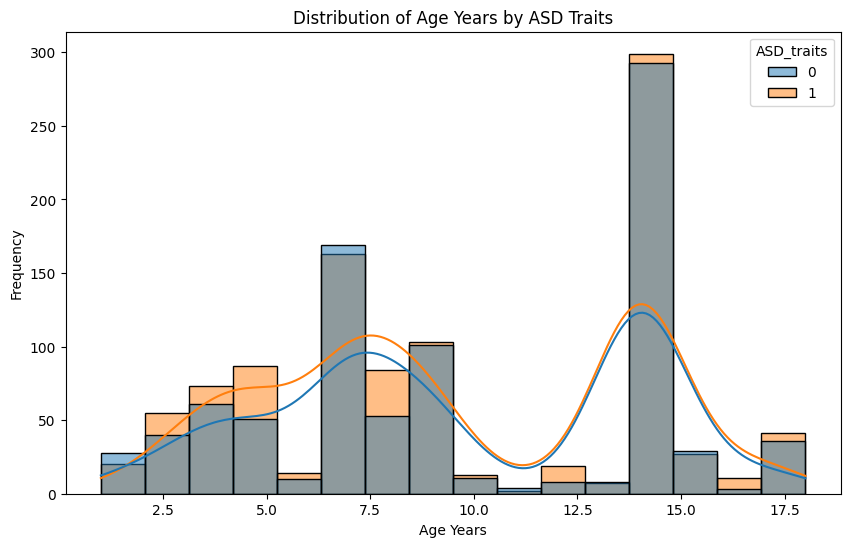

In [18]:
#Deep EDA, Histogram for age
# Note: age distribution may be skewed, revisit during feature engineering

plt.figure(figsize=(10, 6))
sns.histplot(df, x='Age_Years', hue='ASD_traits', kde=True)
plt.title('Distribution of Age Years by ASD Traits')
plt.xlabel('Age Years')
plt.ylabel('Frequency')
plt.show()


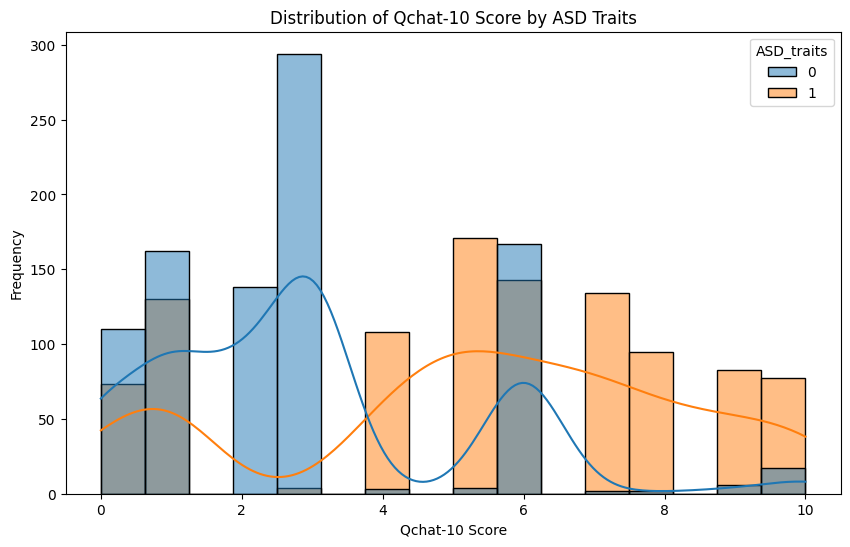

In [19]:
#Deep EDA, Histogram for Qchat
plt.figure(figsize=(10, 6))
sns.histplot(df, x='Qchat_10_Score', hue='ASD_traits', kde=True)
plt.title('Distribution of Qchat-10 Score by ASD Traits')
plt.xlabel('Qchat-10 Score')
plt.ylabel('Frequency')
plt.show()

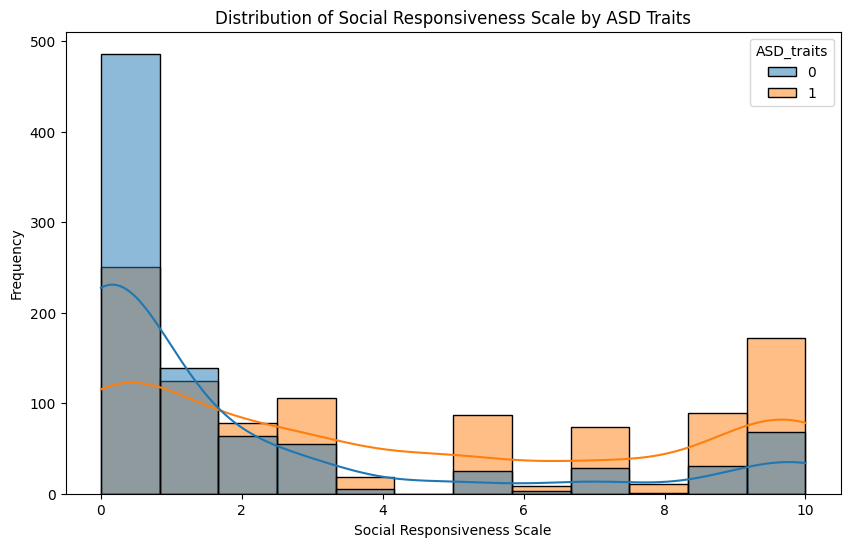

In [20]:
#Deep EDA, Histogram for social responsiveness
plt.figure(figsize=(10, 6))
sns.histplot(df, x='Social_Responsiveness_Scale', hue='ASD_traits', kde=True)
plt.title('Distribution of Social Responsiveness Scale by ASD Traits')
plt.xlabel('Social Responsiveness Scale')
plt.ylabel('Frequency')
plt.show()

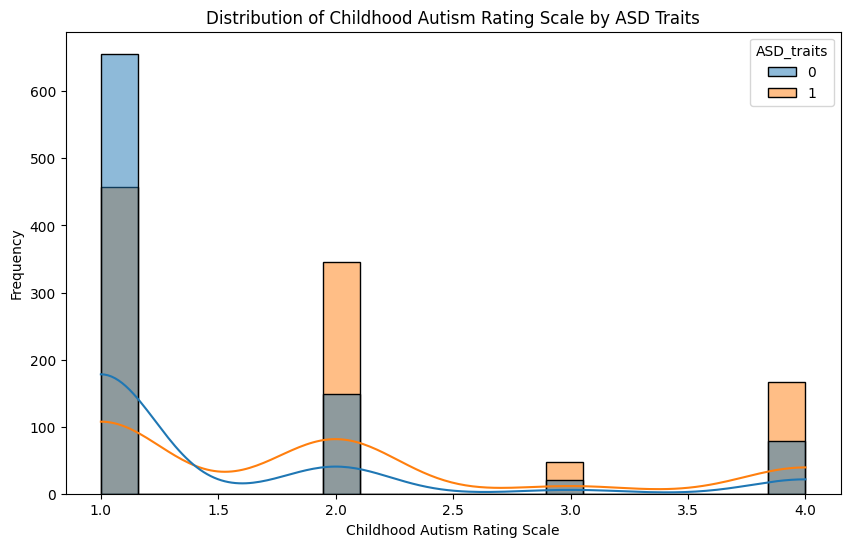

In [21]:
#Deep EDA, Histogram for Childhood Autism Rating Scale
plt.figure(figsize=(10, 6))
sns.histplot(df, x='Childhood Autism Rating Scale', hue='ASD_traits', kde=True)
plt.title('Distribution of Childhood Autism Rating Scale by ASD Traits')
plt.xlabel('Childhood Autism Rating Scale')
plt.ylabel('Frequency')
plt.show()

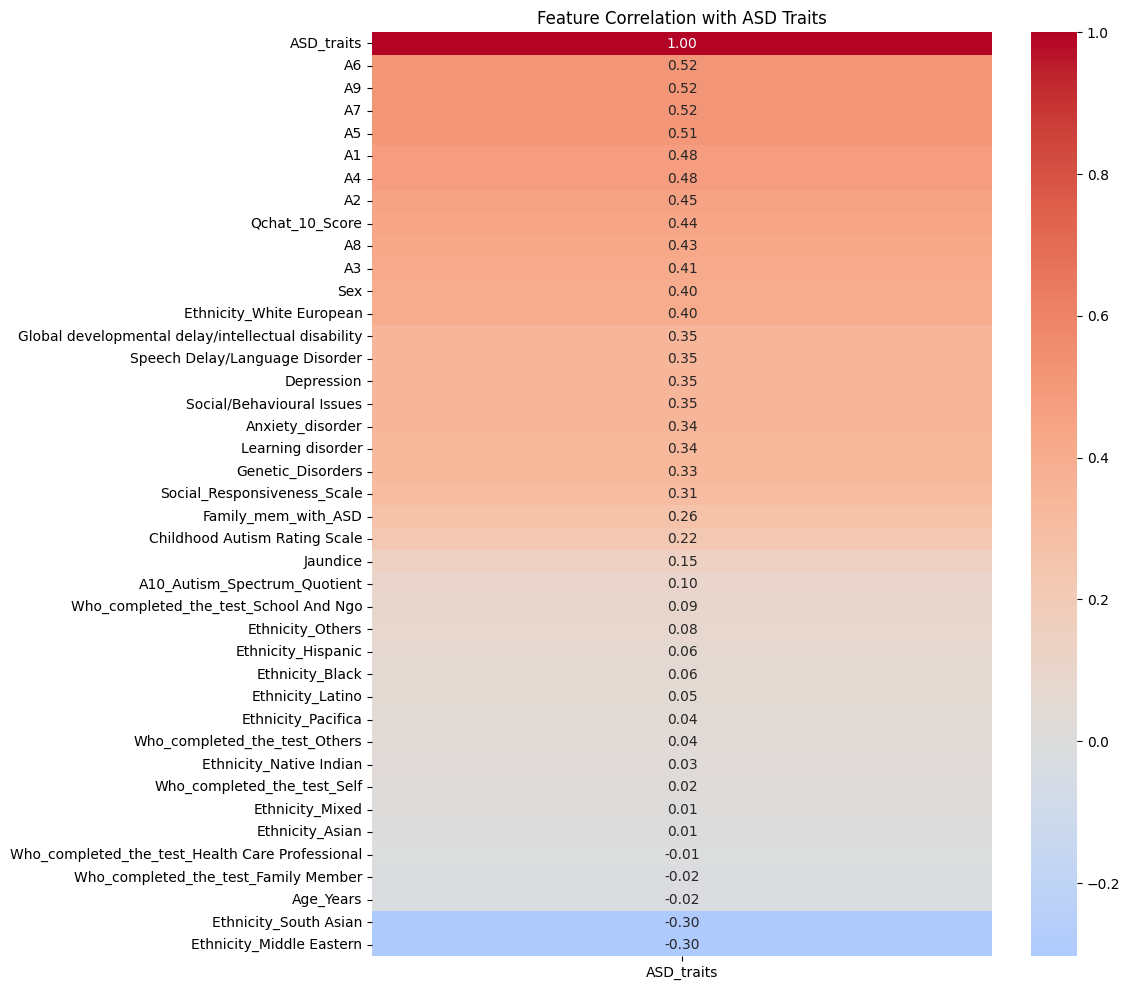

In [22]:
#Correlation heatmap
plt.figure(figsize=(10, 12))
corr = df.corr()[['ASD_traits']].sort_values('ASD_traits', ascending=False)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation with ASD Traits')
plt.show()

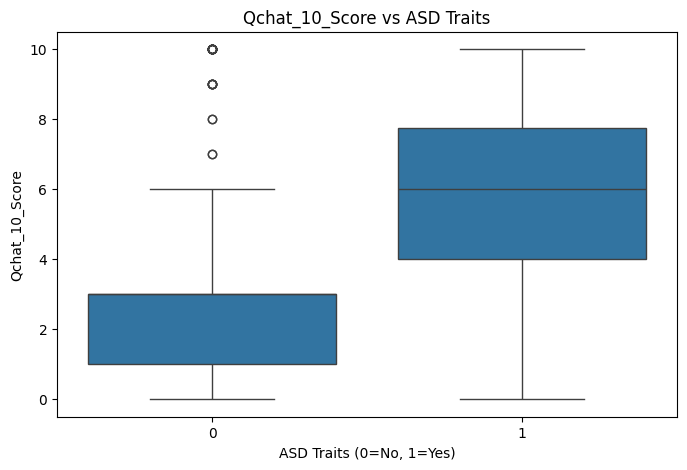

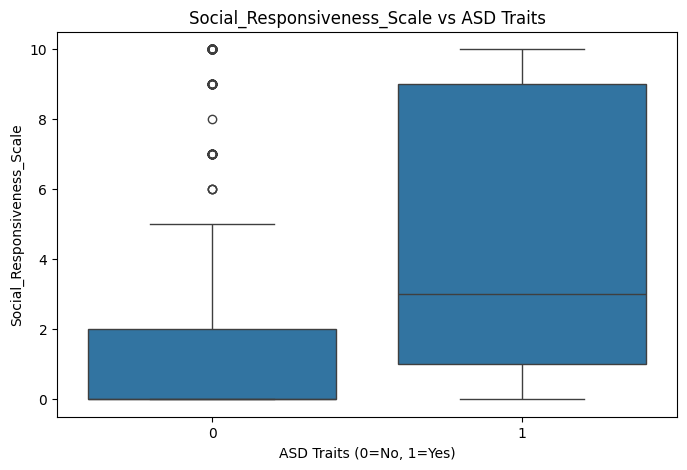

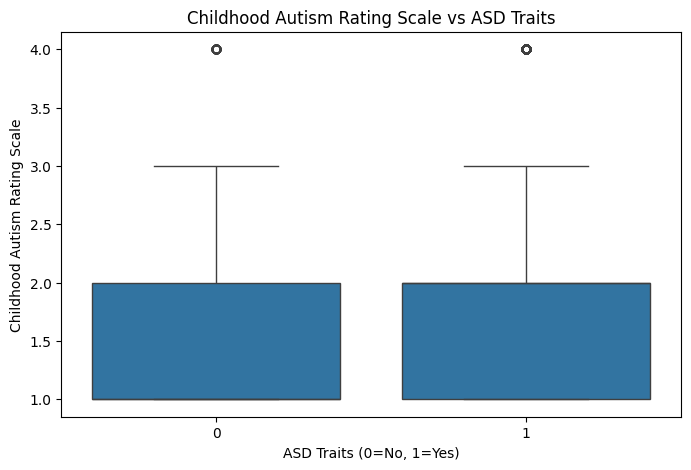

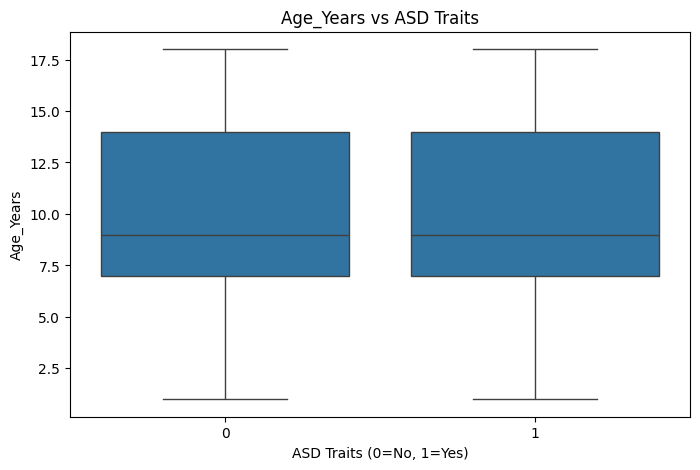

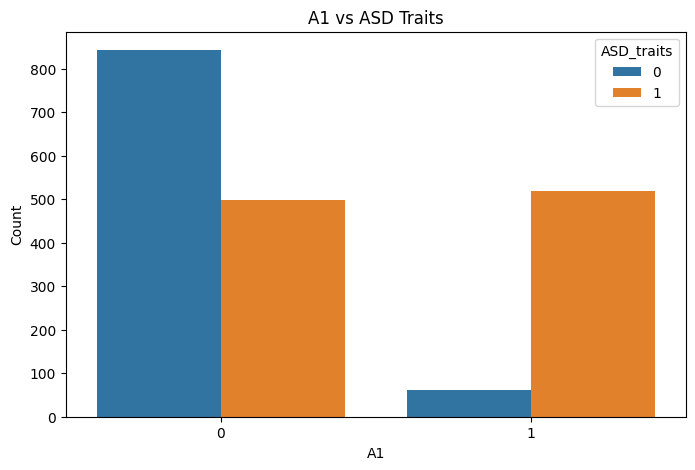

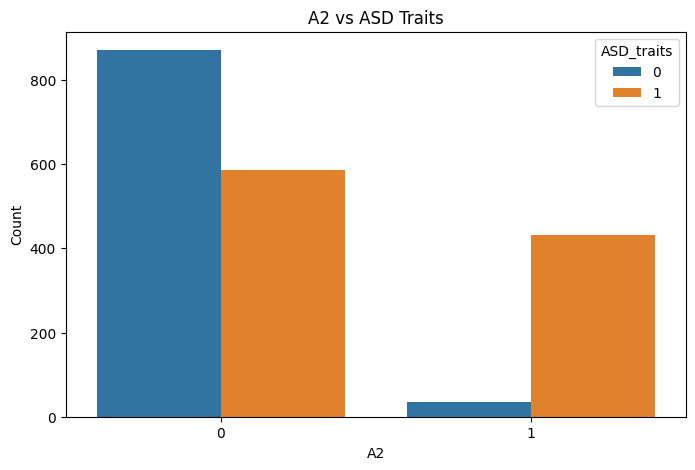

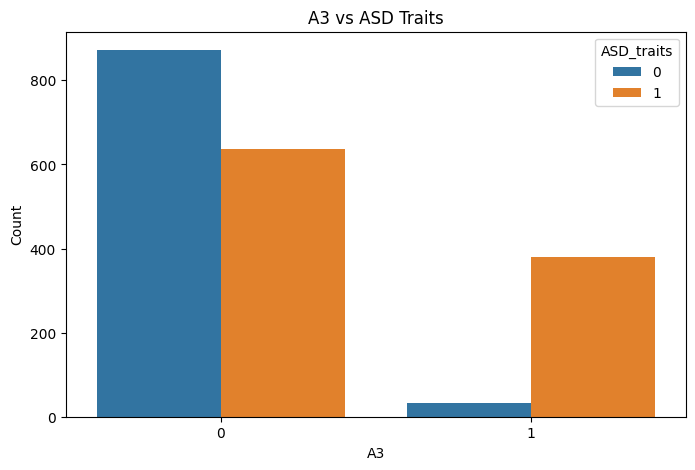

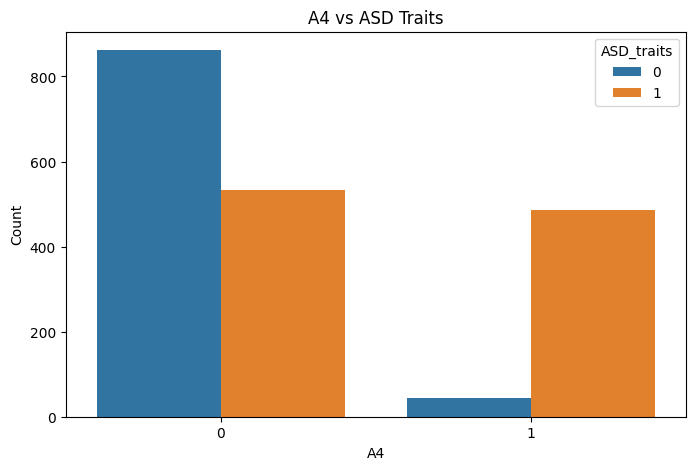

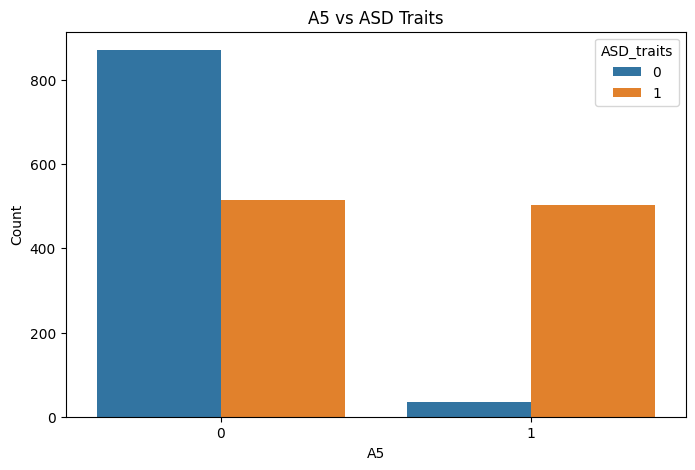

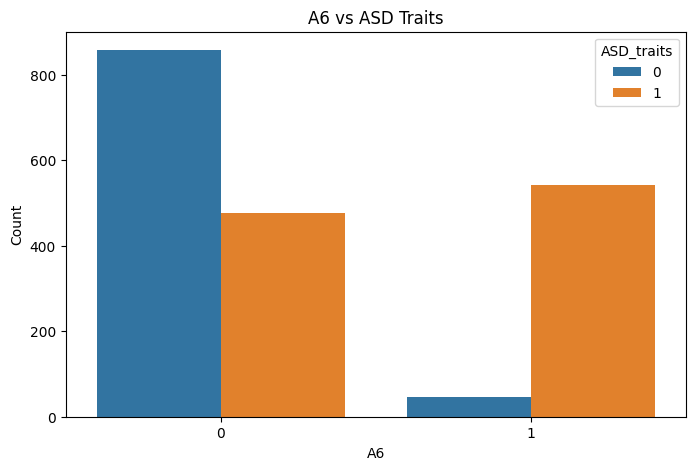

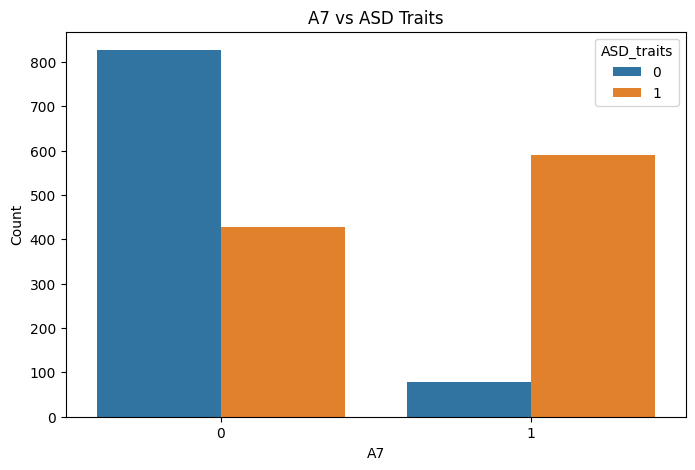

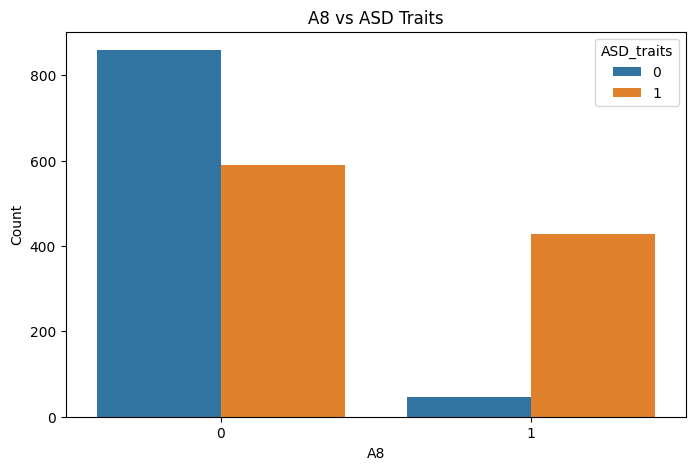

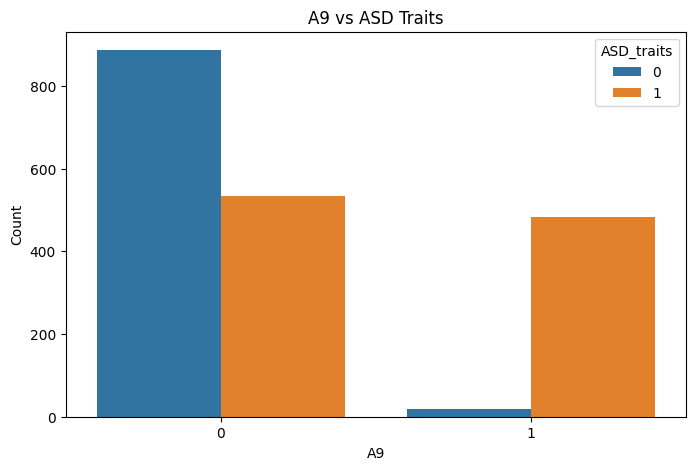

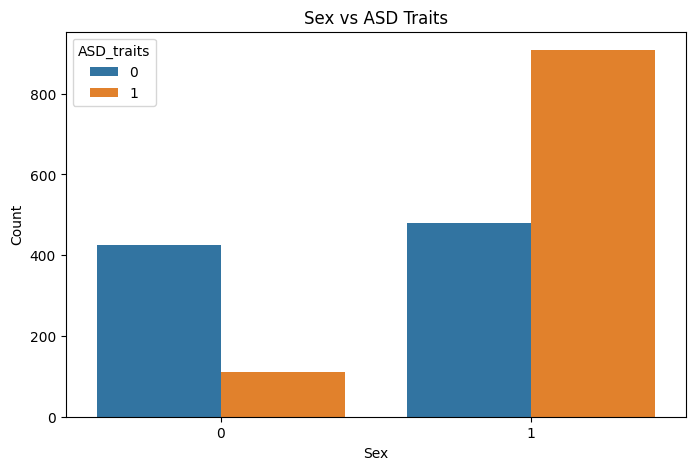

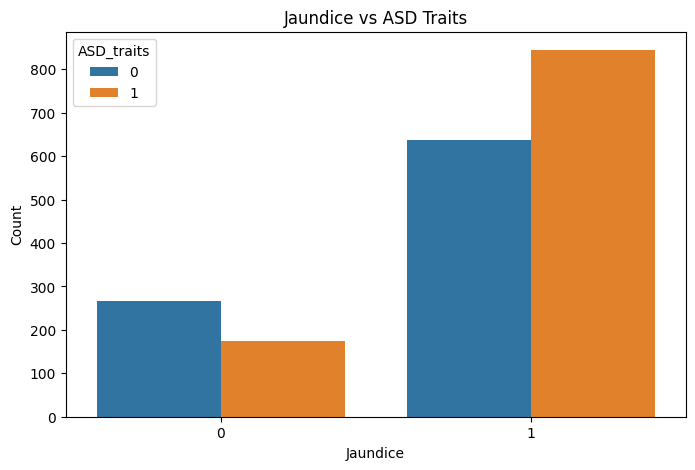

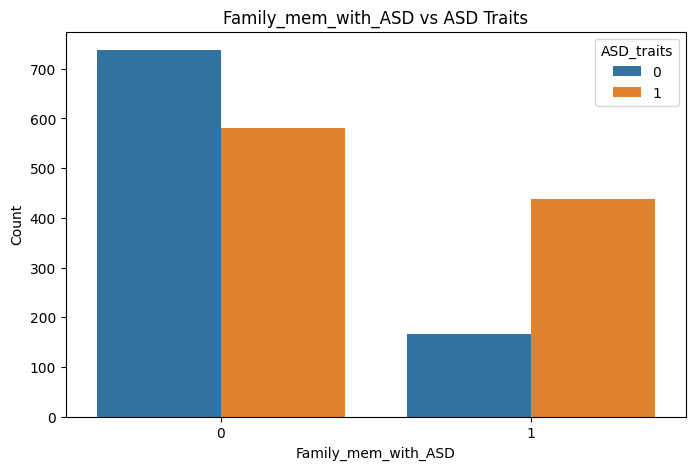

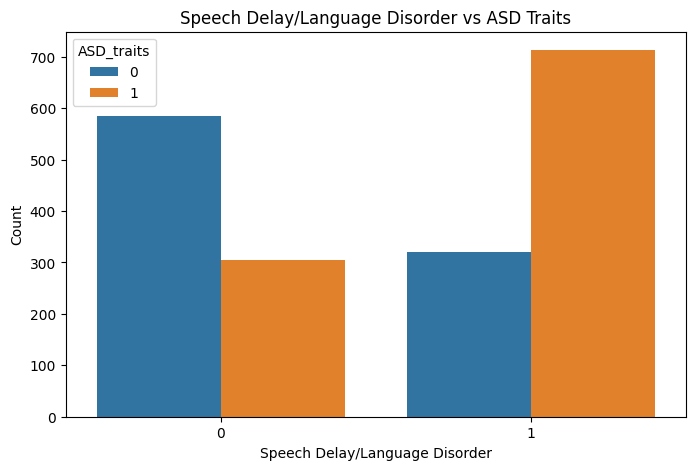

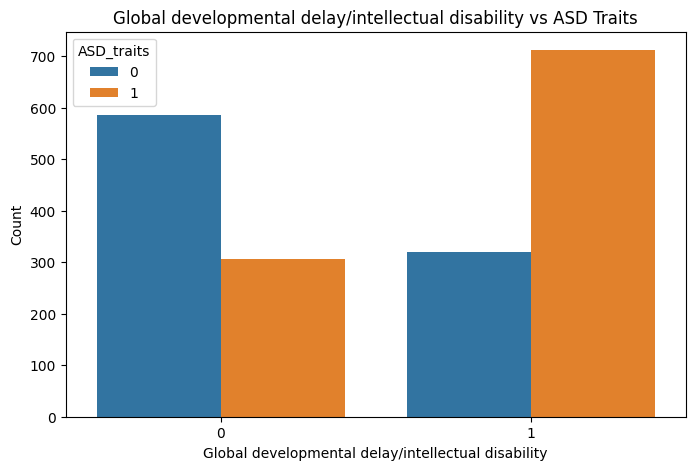

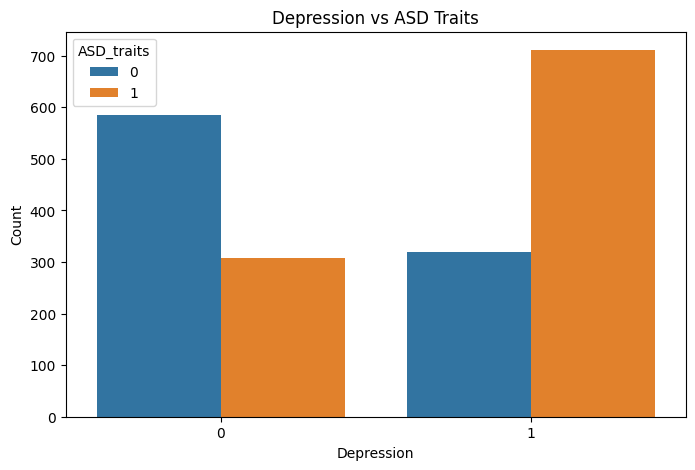

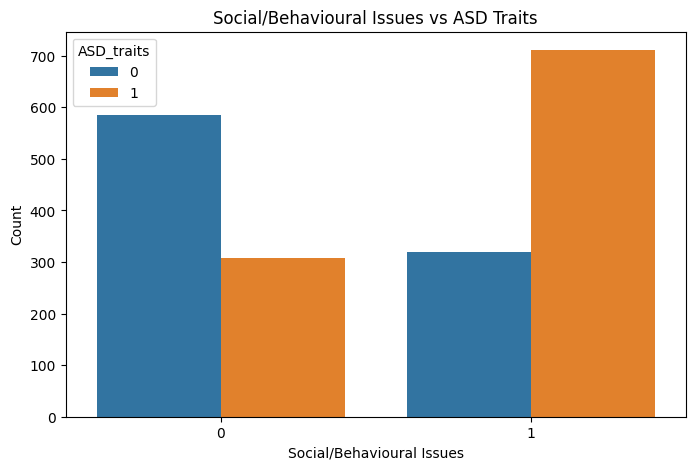

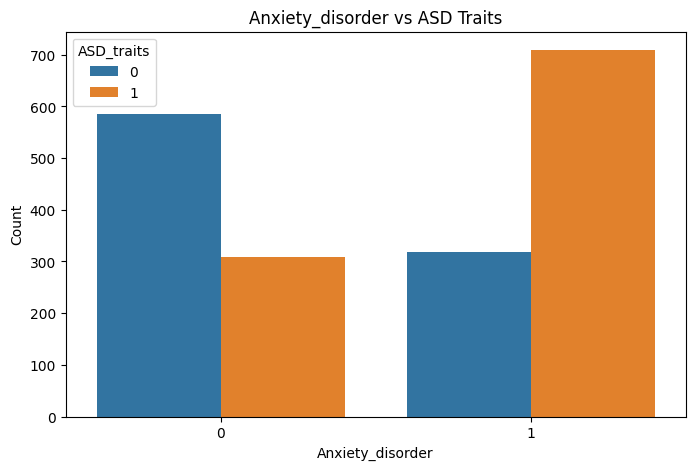

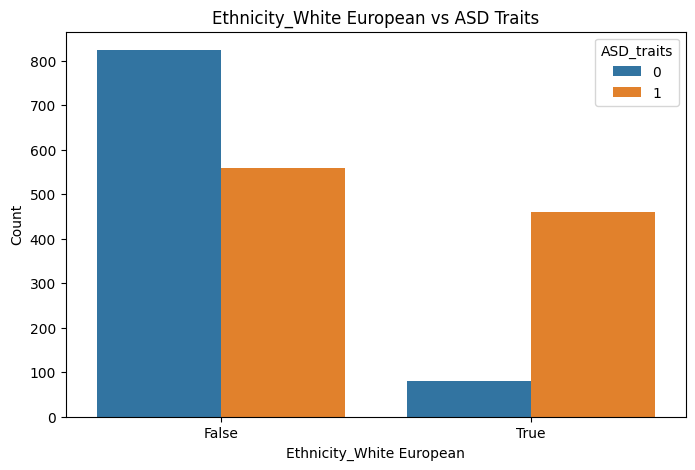

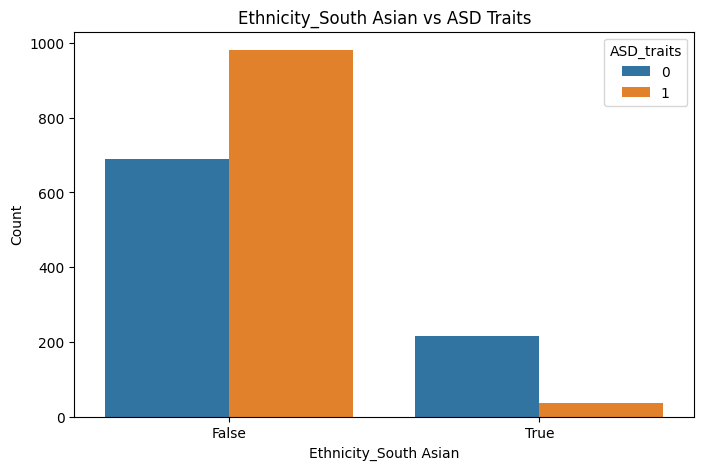

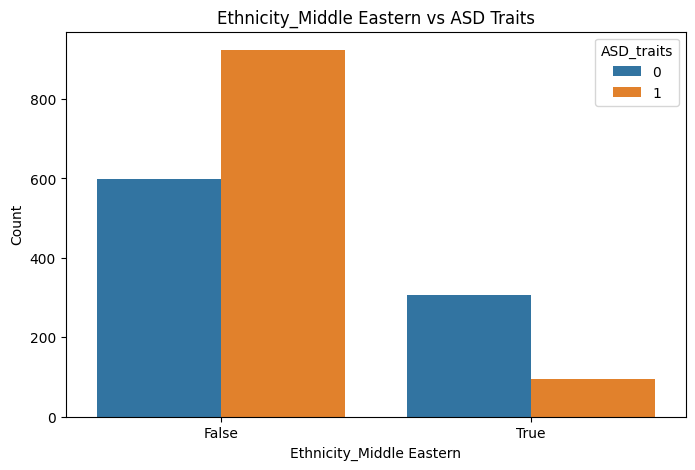

In [23]:
#Feature vs Target
# Numerical features (box plots)
num_cols = ['Qchat_10_Score', 'Social_Responsiveness_Scale', 'Childhood Autism Rating Scale', 'Age_Years']

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='ASD_traits', y=col, data=df)
    plt.title(f'{col} vs ASD Traits')
    plt.xlabel('ASD Traits (0=No, 1=Yes)')
    plt.ylabel(col)
    plt.show()

# Binary features (count plots)
bin_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9',
            'Sex', 'Jaundice', 'Family_mem_with_ASD',
            'Speech Delay/Language Disorder',
            'Global developmental delay/intellectual disability',
            'Depression', 'Social/Behavioural Issues',
            'Anxiety_disorder', 'Ethnicity_White European',
            'Ethnicity_South Asian', 'Ethnicity_Middle Eastern']

for col in bin_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, hue='ASD_traits', data=df)
    plt.title(f'{col} vs ASD Traits')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

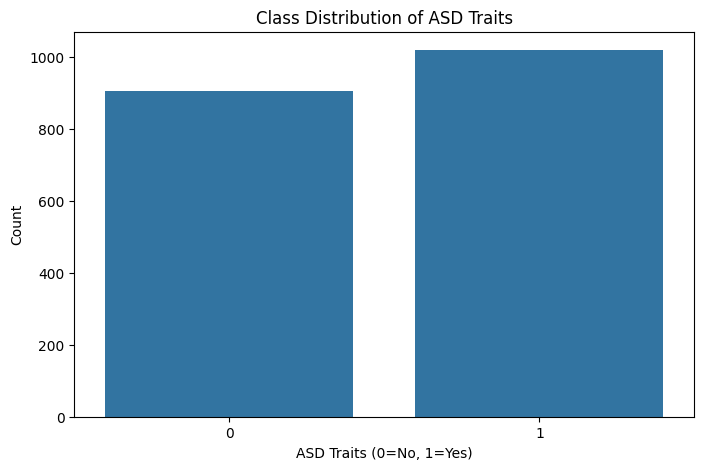

ASD_traits
1    1018
0     905
Name: count, dtype: int64

Class balance: {1: 52.94, 0: 47.06}%


In [24]:
#Class distribution
# Class distribution is relatively balanced (53% ASD, 47% non-ASD).
# SMOTE will still be applied as a precautionary measure to achieve
# a perfect 50/50 split rather than as a critical fix.
plt.figure(figsize=(8, 5))
sns.countplot(x='ASD_traits', data=df)
plt.title('Class Distribution of ASD Traits')
plt.xlabel('ASD Traits (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

print(df['ASD_traits'].value_counts())
print(f"\nClass balance: {df['ASD_traits'].value_counts(normalize=True).mul(100).round(2).to_dict()}%")

In [25]:
#  EDA SUMMARY

# HISTOGRAMS:
# - Qchat-10 scores are higher in ASD children, confirming the
#   questionnaire effectively separates the two groups
# - Social Responsiveness Scale shows ASD children scoring higher,
#   non-ASD children clustered at 0
# - Childhood Autism Rating Scale shows higher ratings associated
#   with ASD but box plot revealed limited separation between groups
# - Age distribution showed a spike in ASD cases at age 13-15,
#   may reflect uneven age representation in the dataset

# CORRELATION HEATMAP:
# - A6, A7, A9, A5 were strongest predictors (0.52)
# - Sex showed strong correlation (0.40)
# - Ethnicity_White European (0.40), South Asian and Middle
#   Eastern (-0.30) showed meaningful correlations
# - Age_Years, most Ethnicity and Who_completed_the_test columns
#   were near zero - candidates for dropping

# FEATURE VS TARGET:
# - Males significantly more likely to have ASD traits than females,
#   consistent with real world clinical research
# - Depression, anxiety, social/behavioural issues and developmental
#   delay all showed clear association with ASD traits
# - Age_Years and Childhood Autism Rating Scale showed identical
#   distributions between groups - confirmed as weak predictors

# CLASS DISTRIBUTION:
# - Dataset relatively balanced: 53% ASD, 47% non-ASD
# - SMOTE applied as precautionary measure, not a critical fix

In [26]:
# Features dropped based on EDA findings:
# - Near zero correlation (<0.1) indicates no meaningful predictive signal
# - Box plots confirmed Age_Years and Childhood Autism Rating Scale
#   show identical distributions between ASD and non-ASD groups
# - Weak features add noise and reduce model performance
# - Sex and ethnicity removed for ethical fairness — demographic features
#   should not influence a clinical screening tool

df.drop(columns=[
    'Age_Years',
    'Childhood Autism Rating Scale',
    'A10_Autism_Spectrum_Quotient',
    'Ethnicity_Others',
    'Ethnicity_Hispanic',
    'Ethnicity_Black',
    'Ethnicity_Latino',
    'Ethnicity_Pacifica',
    'Ethnicity_Native Indian',
    'Ethnicity_Mixed',
    'Ethnicity_Asian',
    'Ethnicity_White European',
    'Ethnicity_South Asian',
    'Ethnicity_Middle Eastern',
    'Who_completed_the_test_Others',
    'Who_completed_the_test_Self',
    'Who_completed_the_test_Health Care Professional',
    'Who_completed_the_test_Family Member',
    'Sex'
], inplace=True)

print(f"Remaining features: {df.shape[1]}")
print(df.columns.tolist())

Remaining features: 22
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'Social_Responsiveness_Scale', 'Qchat_10_Score', 'Speech Delay/Language Disorder', 'Learning disorder', 'Genetic_Disorders', 'Depression', 'Global developmental delay/intellectual disability', 'Social/Behavioural Issues', 'Anxiety_disorder', 'Jaundice', 'Family_mem_with_ASD', 'ASD_traits', 'Who_completed_the_test_School And Ngo']


In [27]:
#Feature engineering
# Define features and target
X = df.drop(columns=['ASD_traits'])
y = df['ASD_traits']

In [28]:
#Train/test split

# Splitting data into 80% training and 20% testing
# random_state=42 ensures the same split every run for reproducibility
# The previous project lacked this step - training and testing on the same

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (1538, 21)
Testing set: (385, 21)


In [29]:
#Preprocessing

In [30]:
# Preprocessing - RobustScaler
# Fit on training data only to prevent data leakage
# Transform both training and testing data

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# SMOTE - applied to training data only
# Dataset is relatively balanced (53/47) so this is precautionary
# Test set remains untouched to reflect real world distribution

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_resampled).value_counts().to_dict()}")

Before SMOTE: {1: 804, 0: 734}
After SMOTE: {1: 804, 0: 804}


In [32]:
#initialise model (RF, LR)
# Initialise models
rf = RandomForestClassifier(random_state=42)
lr = LogisticRegression(random_state=42, max_iter=1000)

In [33]:
#hyperparamter grids both models
# Hyperparameter grid for Random Forest
# Updated hyperparameter grid for Random Forest
param_dist_rf = {
    'n_estimators': randint(50, 300),        # Reduced upper range
    'max_depth': randint(3, 10),             # Reduced depth to prevent overfitting
    'min_samples_split': randint(10, 50),    # Increased minimum to be more conservative
    'min_samples_leaf': randint(5, 20),      # Increased minimum leaf size
    'bootstrap': [True, False],
    'max_features': randint(1, X_train_resampled.shape[1])
}

# Hyperparameter grid for Logistic Regression
param_dist_lr = {
    'C': uniform(0.01, 10),                  # Regularisation strength
    'penalty': ['l1', 'l2'],                 # Type of regularisation
    'solver': ['liblinear', 'saga'],         # Optimisation algorithm
    'max_iter': randint(100, 1000)           # Maximum iterations
}

In [34]:

# RandomizedSearchCV for Random Forest
random_search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=50,           # Number of random combinations to try
    cv=5,                # 5-fold cross validation
    verbose=2,           # Track progress
    random_state=42,     # Reproducibility
    n_jobs=-1,           # Use all available cores
    scoring='f1'         # Classification metric
)

In [35]:
# RandomizedSearchCV for Logistic Regression
random_search_lr = RandomizedSearchCV(
    lr,
    param_distributions=param_dist_lr,
    n_iter=50,           # Number of random combinations to try
    cv=5,                # 5-fold cross validation
    verbose=2,           # Track progress
    random_state=42,     # Reproducibility
    n_jobs=-1,           # Use all available cores
    scoring='f1'         # Classification metric
)

In [36]:
# Fit both models
random_search_rf.fit(X_train_resampled, y_train_resampled)
random_search_lr.fit(X_train_resampled, y_train_resampled)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=LogisticRegression(max_iter=1000, random_state=42),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c06242b2960>,
                                        'max_iter': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c0624282300>,
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear', 'saga']},
                   random_state=42, scoring='f1', verbose=2)

In [37]:
# Best parameters for Random Forest
print("Best RF Parameters:", random_search_rf.best_params_)
print("Best RF F1 Score:", random_search_rf.best_score_)

# Best parameters for Logistic Regression
print("\nBest LR Parameters:", random_search_lr.best_params_)
print("Best LR F1 Score:", random_search_lr.best_score_)

Best RF Parameters: {'bootstrap': False, 'max_depth': 9, 'max_features': 8, 'min_samples_leaf': 9, 'min_samples_split': 25, 'n_estimators': 286}
Best RF F1 Score: 0.9153701615095324

Best LR Parameters: {'C': np.float64(2.7699918202254334), 'max_iter': 256, 'penalty': 'l1', 'solver': 'liblinear'}
Best LR F1 Score: 0.8684504813764514


In [38]:
# Cross validation for both models
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest cross validation
cv_results_rf = cross_val_score(random_search_rf.best_estimator_,
                                X_train_resampled, y_train_resampled,
                                cv=kf, scoring='f1')

print(f"RF Cross-validated F1: {np.mean(cv_results_rf):.4f}")
print(f"RF Standard Deviation: {np.std(cv_results_rf):.4f}")

# Logistic Regression cross validation
cv_results_lr = cross_val_score(random_search_lr.best_estimator_,
                                X_train_resampled, y_train_resampled,
                                cv=kf, scoring='f1')

print(f"\nLR Cross-validated F1: {np.mean(cv_results_lr):.4f}")
print(f"LR Standard Deviation: {np.std(cv_results_lr):.4f}")

RF Cross-validated F1: 0.9167
RF Standard Deviation: 0.0175

LR Cross-validated F1: 0.8637
LR Standard Deviation: 0.0200


In [39]:
# Apply both models on test data
y_pred_rf = random_search_rf.best_estimator_.predict(X_test_scaled)
y_pred_lr = random_search_lr.best_estimator_.predict(X_test_scaled)

In [40]:
#evaluate both models on test data
# Evaluation for Random Forest
print("=" * 50)
print("RANDOM FOREST EVALUATION")
print("=" * 50)
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Evaluation for Logistic Regression
print("\n" + "=" * 50)
print("LOGISTIC REGRESSION EVALUATION")
print("=" * 50)
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

RANDOM FOREST EVALUATION
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       171
           1       1.00      0.79      0.89       214

    accuracy                           0.89       385
   macro avg       0.90      0.90      0.89       385
weighted avg       0.91      0.89      0.89       385

Confusion Matrix:
[[171   0]
 [ 44 170]]

LOGISTIC REGRESSION EVALUATION
              precision    recall  f1-score   support

           0       0.71      0.95      0.82       171
           1       0.95      0.70      0.80       214

    accuracy                           0.81       385
   macro avg       0.83      0.82      0.81       385
weighted avg       0.85      0.81      0.81       385

Confusion Matrix:
[[163   8]
 [ 65 149]]


In [41]:
# ============================================================
#  MODEL EVALUATION SUMMARY
# ============================================================

# RANDOM FOREST (Primary Model):
# - Accuracy: 89% - correctly identified 89 out of 100 children
# - Precision: 1.00 - when predicting ASD, always correct
# - Recall: 0.79 - caught 79% of real ASD cases, missed 44
# - F1 Score: 0.89 - good balance between precision and recall
# - Cross validated F1: 0.9167 with std of 0.0175 - consistent
# - Confusion matrix: 171 correct no-ASD, 170 correct ASD,
#   0 false positives, 44 false negatives

# LOGISTIC REGRESSION:
# - Accuracy: 81% - similar performance to Random Forest
# - Precision: 0.95 - good at avoiding false positives
# - Recall: 0.70 - missed 30% of real ASD cases (65 children)
# - F1 Score: 0.80 - weaker balance between precision and recall
# - Cross validated F1: 0.8637 with std of 0.0200
# - Confusion matrix: 163 correct no-ASD, 149 correct ASD,
#   8 false positives, 65 false negatives

# KEY FINDINGS:
# - Sex and ethnicity removed for ethical and clinical fairness
# - Removing demographic features reduced RF accuracy from 96% to 89%
# - This tradeoff is justified - model now makes decisions purely
#   on behavioural and clinical features
# - Random Forest selected as primary model - higher recall and
#   more consistent cross validation performance
# - LR missing 65 ASD cases is clinically unacceptable

# CLINICAL IMPORTANCE:
# - Recall is the most critical metric for a screening tool
# - A false negative means a child misses early intervention
# - RF precision of 1.00 means zero false positives - no healthy
#   children wrongly flagged
# - 89% accuracy outperforms the Q-Chat tool itself (80-85%)
# - Model is built on purely behavioural and clinical signals
#   making it fair and ethically defensible
# ============================================================

In [42]:
# Model comparison summary
print("=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"{'Metric':<25} {'Random Forest':<20} {'Logistic Regression'}")
print("-" * 65)
print(f"{'Accuracy':<25} {'89%':<20} {'81%'}")
print(f"{'Precision (ASD)':<25} {'1.00':<20} {'0.95'}")
print(f"{'Recall (ASD)':<25} {'0.79':<20} {'0.70'}")
print(f"{'F1 Score':<25} {'0.89':<20} {'0.80'}")
print(f"{'Cross-val F1':<25} {'0.92':<20} {'0.86'}")
print(f"{'Missed ASD cases':<25} {'44':<20} {'65'}")
print("-" * 65)
print("\nRandom Forest selected as primary model.")
print("Higher recall, precision and cross-validation consistency.")
print("LR missing 65 ASD cases is clinically unacceptable.")

MODEL COMPARISON SUMMARY
Metric                    Random Forest        Logistic Regression
-----------------------------------------------------------------
Accuracy                  89%                  81%
Precision (ASD)           1.00                 0.95
Recall (ASD)              0.79                 0.70
F1 Score                  0.89                 0.80
Cross-val F1              0.92                 0.86
Missed ASD cases          44                   65
-----------------------------------------------------------------

Random Forest selected as primary model.
Higher recall, precision and cross-validation consistency.
LR missing 65 ASD cases is clinically unacceptable.


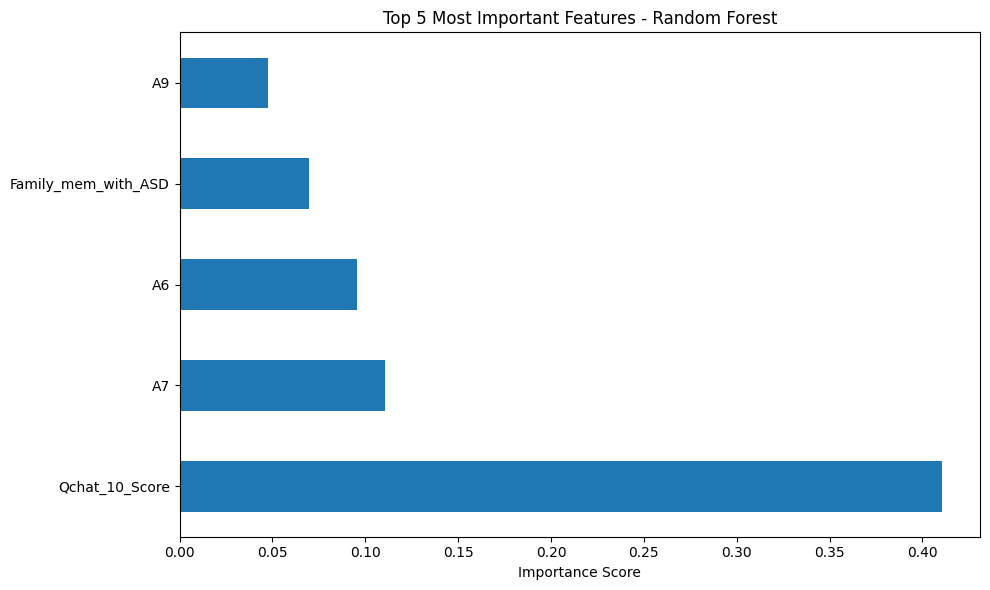

Qchat_10_Score         0.410458
A7                     0.110628
A6                     0.095276
Family_mem_with_ASD    0.069535
A9                     0.047404
dtype: float64


In [43]:
# Feature importance for Random Forest
feature_importance_rf = pd.Series(
    random_search_rf.best_estimator_.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance_rf.head(5).plot(kind='barh')
plt.title('Top 5 Most Important Features - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feature_importance_rf.head(5))

In [44]:
# ============================================================
#  FEATURE IMPORTANCE SUMMARY
# ============================================================

# TOP 5 MOST IMPORTANT FEATURES (Random Forest):
# 1. Qchat_10_Score (0.41) - dominant predictor, total questionnaire
#    score accounts for 41% of model decisions
# 2. A7 (0.11) - child shows distress when routines change,
#    core autism characteristic
# 3. A6 (0.10) - child follows where you are looking,
#    difficulty with joint attention is earliest detectable sign
# 4. Family_mem_with_ASD (0.07) - family history reflects
#    well established genetic component of autism
# 5. A9 (0.05) - child stares at nothing with no apparent purpose,
#    recognised early behavioural indicator

# KEY FINDING:
# - All top 5 features are purely behavioural and clinical
# - No demographic features present after ethical feature removal
# - Simple parent reported observations are strongest predictors
# - Family history emerging as 4th most important validates
#   genetic link in autism research
# ============================================================

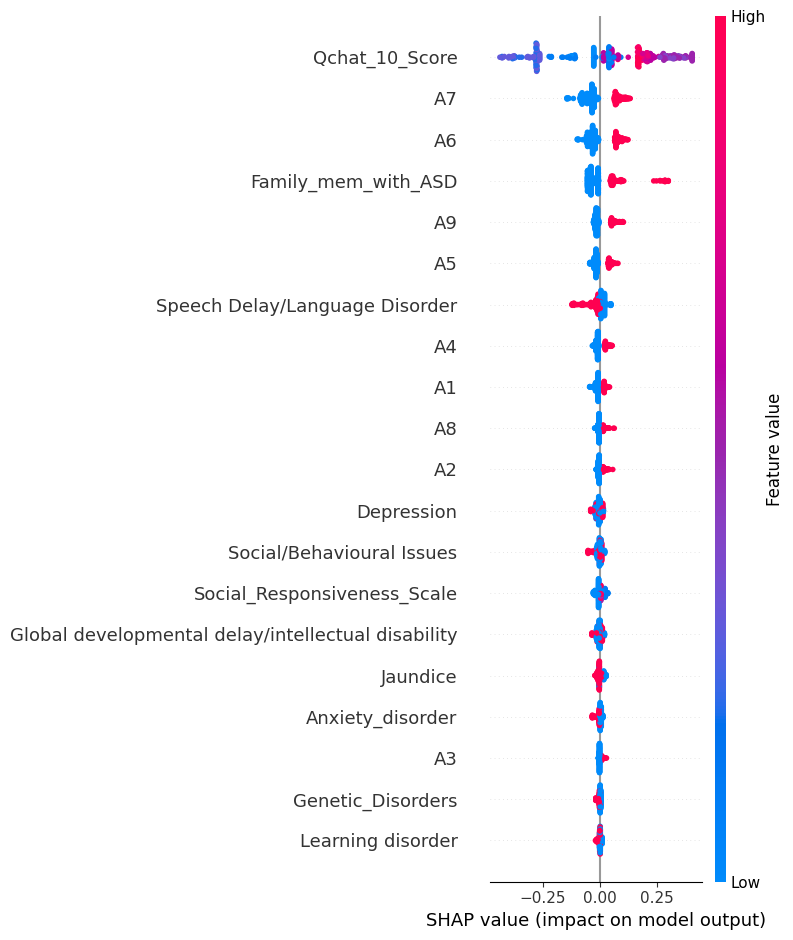

In [45]:
# SHAP analysis for Random Forest
explainer = shap.TreeExplainer(random_search_rf.best_estimator_)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(12, 16))
shap.summary_plot(shap_values[:,:,1], X_test_scaled,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.tight_layout()
plt.show()

In [46]:
# ============================================================
#  SHAP ANALYSIS SUMMARY
# ============================================================

# SHAP explains how each feature influences individual predictions
# Right of centre = pushes towards ASD prediction (1)
# Left of centre = pushes away from ASD prediction (0)
# Red dots = high feature value, Blue dots = low feature value

# KEY FINDINGS:

# Qchat_10_Score - dominant predictor
# - High scores (red) push strongly towards ASD prediction
# - Low scores (blue) push strongly away from ASD prediction
# - Widest spread confirming it as the single most influential feature

# A7, A6, A9, A5 - behavioural questions
# - Answering yes (red) consistently pushes towards ASD
# - Answering no (blue) consistently pushes away from ASD
# - Clean pattern validating Q-Chat questions as strong indicators

# Family_mem_with_ASD
# - Having family history (red) pushes towards ASD prediction
# - Validates well established genetic component of autism

# Speech Delay/Language Disorder
# - Counterintuitively pushes away from ASD when present
# - Likely reflects dataset collection bias, noted as limitation

# Depression, Social/Behavioural Issues, Anxiety
# - Small but consistent push towards ASD when present
# - Confirms comorbidities play a supporting role in prediction

# A3, Genetic_Disorders, Learning disorder
# - Clustered near zero, minimal influence on predictions
# - Candidates for removal in future model iterations

# OVERALL:
# - All influential features are behavioural and clinical
# - No demographic bias present in final model
# - Results are clinically coherent and defensible
# ============================================================